In [11]:
import torch
from torch import nn
import torchvision as tv
import time
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
BATCH_SIZE = 256 # Весь набор данных разбивается на "батчи" - связки по 256 объектов

In [3]:
transforms = tv.transforms.Compose([
    tv.transforms.Resize(32),
    tv.transforms.ToTensor()
])

In [4]:
train_dataset = tv.datasets.MNIST('.',
                                  train=True,
                                  transform=transforms,
                                  download=True)

test_dataset = tv.datasets.MNIST('.',
                                 train=False,
                                 transform=transforms,
                                 download=True)

train_iter = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE)
test_iter = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE)

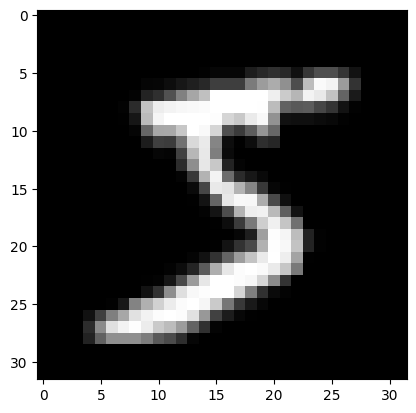

In [ ]:
train_dataset[0]
plt.imshow(train_dataset[0][0].numpy().reshape(32,32), cmap='gray');

In [6]:
model = nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5, padding=0),
    nn.ReLU(),
    nn.AvgPool2d(2, stride=2),
    nn.Conv2d(6, 16, kernel_size=5),
    nn.ReLU(),
    nn.AvgPool2d(2, stride=2),
    nn.Conv2d(16, 64, kernel_size=5),
    nn.Flatten(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 10)
)

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device = "cpu"

model = model.to(device)

In [16]:
def evaluate_accuracy(data_iter, net):
    acc_sum, n = torch.Tensor([0]), 0
    for X, y in data_iter:
        acc_sum += (net(X).argmax(axis=1) == y).sum()
        n += y.shape[0]
    return acc_sum.item() / n

In [17]:
def train(net, train_iter, test_iter, optimizer, num_epochs):
    loss = nn.CrossEntropyLoss()

    for epoch in range(num_epochs):
        train_l_sum, train_acc_sum, n, start = 0.0, 0.0, 0, time.time()
        
        progress_bar = tqdm(train_iter, desc=f'Epoch {epoch+1}/{num_epochs}')

        for X, y in progress_bar:
            optimizer.zero_grad() # обнуляем градиенты
            y_hat = net(X) # предсказываем значения
            l = loss(y_hat, y) # счтаем функцию потерь
            l.backward() # считаем градиенты, которые останутся "на парметрах"
            optimizer.step() # делаем шаг, градиент в параметрах
            train_l_sum += l.item()
            train_acc_sum += (y_hat.argmax(axis=1) == y).sum().item()
            n += y.shape[0]
            
            progress_bar.set_postfix({
                'loss': f'{l.item():.4f}',
                'acc': f'{(train_acc_sum / n):.4f}'
            })

        test_acc = evaluate_accuracy(test_iter, net)
        print(f'epoch {epoch + 1}, loss {train_l_sum / n:.4f}, train acc {train_acc_sum / n:.3f}' \
              f', test acc {test_acc:.3f}, time {time.time() - start:.1f} sec')

In [18]:
lr, num_epochs = 0.01, 10
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
train(model, train_iter, test_iter, optimizer, num_epochs)

Epoch 1/10: 100%|██████████| 235/235 [00:28<00:00,  8.13it/s, loss=0.2087, acc=0.9808]


epoch 1, loss 0.0003, train acc 0.981, test acc 0.982, time 31.6 sec


Epoch 2/10: 100%|██████████| 235/235 [00:21<00:00, 10.79it/s, loss=0.1565, acc=0.9845]


epoch 2, loss 0.0002, train acc 0.984, test acc 0.982, time 24.2 sec


Epoch 3/10: 100%|██████████| 235/235 [00:22<00:00, 10.67it/s, loss=0.1310, acc=0.9854]


...

epoch 8, loss 0.0001, train acc 0.989, test acc 0.985, time 22.6 sec


Epoch 9/10: 100%|██████████| 235/235 [00:25<00:00,  9.04it/s, loss=0.0431, acc=0.9895]


epoch 9, loss 0.0001, train acc 0.989, test acc 0.987, time 28.5 sec


Epoch 10/10: 100%|██████████| 235/235 [00:23<00:00, 10.05it/s, loss=0.2494, acc=0.9900]


epoch 10, loss 0.0001, train acc 0.990, test acc 0.985, time 26.3 sec
